# Algorithmic Chains and Pipelines

This chapter covers how to use the `Pipeline` class.

**Example.** *(The Cancer Dataset)*

Performance of the kernel SVM can be greatly improved by preprocessing the dataset using the `MinMaxScaler`.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mglearn
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
%matplotlib inline

# Use SVC model and MinMaxScaler for preprocessing
svc = SVC()
scaler = MinMaxScaler()

# Prepare data
dataset = load_breast_cancer()
X = dataset.data
y = dataset.target
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

# Preprocess data
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)

# Fit SVC on scaled data
svc.fit(X_train_scaled, y_train)

# Evaluate SVC
X_test_scaled = scaler.transform(X_test)
score = svc.score(X_test_scaled, y_test)

print('Test score (raw): {:.3f}'.format(SVC().fit(X_train,y_train).score(X_test, y_test)))
print('Test score: {:.3f}'.format(score))

Test score (raw): 0.937
Test score: 0.972


## Parameter Selection with Preprocessing

When using a preprocessing step with a grid search, it is not a good idea to fit the preprocessor (e.g., a scaler) on the first data split (to training-validation and test) before the grid search.

During a grid search with cross validation, the training-validation set is split into a training set and a validation set in each iteration of cross-validation. The validation set is supposed to be new data to the trained model.

If the training-validation set that we use for the grid search is already preprocessed, then the validation set would be fundamentally different from how new data looks to the model -- the validation set must be scaled on its own because it might have a maximum and minimum that is different from the whole training-validation set.

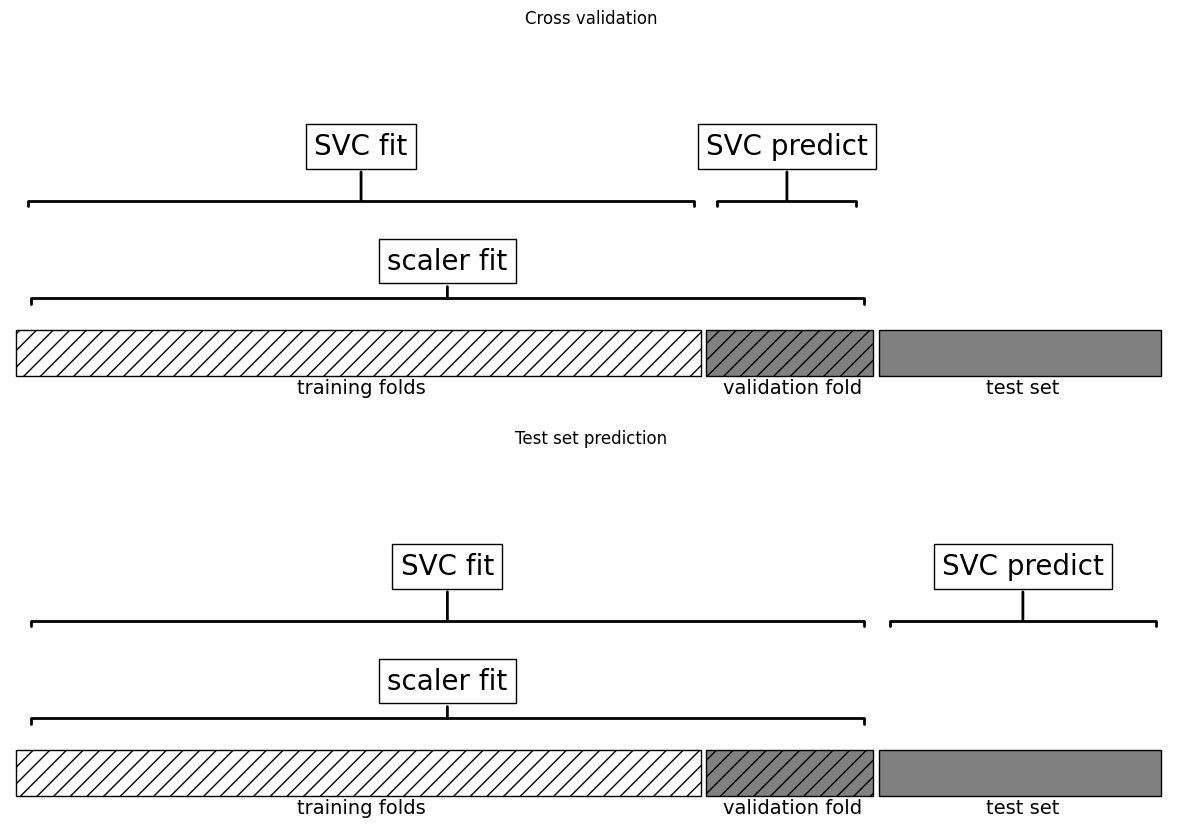

In [11]:
mglearn.plots.plot_improper_processing()

Consequently, the splits in the cross-validation no longer mirror new data, information is already leaked into the process, and the results will be overly optimistic.

**To strictly follow:** <mark>Any process that extracts knowledge from the dataset should only ever be applied to the training portion of the dataset.</mark>

Hence, the splitting for cross-validation should always be at the outer loop of the process.

The work-around is to use the `Pipeline` class of Scikit-learn.

## Building Pipelines

A simple pipeline can be created to combine the `MinMaxScaler` and `SVC` steps in one object.

In [13]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    ('estimator', SVC())
])

# By calling fit, the pipeline automatically fit the scaler and transform the data
# and fits the final estimator
pipeline.fit(X_train, y_train)
score = pipeline.score(X_test, y_test) # X_test, y_test -- transform --> X_test_scaled, y_test -- evaluate --> score! 
print('Test score {:.3f}'.format(score))

Test score 0.972


## Using Pipelines in Grid Searches
Now let's resolve the earlier problem of grid searching with preprocessing.

A slight catch when using the GridSearchCV with a pipeline: we have to define the parameter grid such that the pipeline knows to which step the parameter belongs to. The syntax for the key should be `<pipeline step>__<parameter>`.

In [14]:
from sklearn.model_selection import GridSearchCV

# We can use the pipeline as if it is an estimator
# But unlike an estimator, the pipeline is combined with a preprocessor
param_grid = {'estimator__C': [0.001, 0.01, 0.1, 1, 10, 100],
             'estimator__gamma': [0.001, 0.01, 0.1, 1, 10, 100]}
grid_search = GridSearchCV(pipeline, param_grid)

# Define the training-validation set and test set
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, random_state=0)

# Fit the grid search
grid_search.fit(X_train_val,y_train_val)

# Evaluate the grid search
best_cv_score = grid_search.best_score_
test_score = grid_search.score(X_test, y_test)
best_params = grid_search.best_params_

print('Best cross-validation accuracy: {:.3f}'.format(best_cv_score))
print('Test set score: {:.3f}'.format(test_score))
print('Best parameters: {}'.format(best_params))

Best cross-validation accuracy: 0.981
Test set score: 0.972
Best parameters: {'estimator__C': 1, 'estimator__gamma': 1}


The impact of the information leakage depends on the nature of the preprocessing step. Using the test fold for scaling usually does not have a terrible impact. However, when the test fold is used in feature extraction or feature selection, the impact is substantial.

## The General Pipeline Interface

When calling `Pipeline.fit`, the pipeline calls `fit` and then `transform` at each step, with the input being the output of the transform in the previous step. At the last step, the pipeline just calls `fit`.

After fitting, the `Pipeline.predict` can be called, at which point, the pipeline calls `transform` at each step and then `predict` at the last step.

![pipeline](../assets/pipeline.png)

The pipeline is more general than this. The last step need not be a classifier. It can be an unsupervised model with just a transform method such as PCA. In that case, you can call `Pipeline.transform` instead of predict.

The only requirement is that all but the last step must have a `transform` method.

### Convenient Pipeline Creation with make_pipeline

The convenience function `make_pipeline` can be used to shorten the syntax for creating a pipeline. It automatically names each step based on the class.

In [16]:
from sklearn.pipeline import make_pipeline
pipe = make_pipeline(MinMaxScaler(), SVC(C=100))

steps = pipe.named_steps
print('Pipeline steps:\n {}'.format(steps))

Pipeline steps:
 {'minmaxscaler': MinMaxScaler(), 'svc': SVC(C=100)}


The convenience function returns a `Pipeline` object. So, all the attributes of Pipeline class can be called.

The resulting name will just be the lowercase version of the step. If there are multiple steps having the same class, a number is appended.

In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pipe = make_pipeline(StandardScaler(), PCA(n_components=2), StandardScaler())
steps = pipe.named_steps
print('Pipeline steps:\n {}'.format(steps))

Pipeline steps:
 {'standardscaler-1': StandardScaler(), 'pca': PCA(n_components=2), 'standardscaler-2': StandardScaler()}


### Accessing Step Attributes
You can access pipeline steps using the `named_steps` attribute of the pipeline, which is a dictionary containing the steps as values and the names of the steps as keys.

In [20]:
pipe.fit(X,y)
PCA_components = steps['pca'].components_
print('components.shape: {}'.format(PCA_components.shape))

components.shape: (2, 30)


### Accessing Attributes in a Grid-Searched Pipeline

When a pipeline is used with grid search, the resulting best estimator is a pipeline where each step is tuned with the best parameters. So, the pipeline can be accessed with the `best_estimator_` attribute of the grid search. The pipeline steps can then be accessed with the `named_steps` attribute as before.

Let's fit a logistic regression model on the cancer dataset preprocessed with the `MinMaxScaler`.

In [21]:
from sklearn.linear_model import LogisticRegression

param_grid = {'logisticregression__C': [0.01, 0.1, 1, 10, 100]}
pipeline = make_pipeline(MinMaxScaler(), LogisticRegression())
grid = GridSearchCV(pipeline, param_grid)

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, random_state=0)
grid.fit(X_train_val, y_train_val)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'logisticregression__C': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: int, default=0Controls the verbosity of information printed duri

Now, suppose we want to access the coefficients of the tuned logistic regression model.
1. Get the tuned pipeline with the `best_estimator_` attribute
2. Access the logistic regression model with `named_steps`
3. Access the coefficients with the `coef_` attribute.

In [22]:
best_pipe = grid.best_estimator_
logreg = best_pipe.named_steps['logisticregression']
coef = logreg.coef_

print('Logistic regression coefficients:\n {}'.format(coef))

Logistic regression coefficients:
 [[ -0.19064183  -4.90137568  -0.30574348  -2.08528906  -0.64969513
    5.59838179  -5.34270005  -6.86167289  -3.85406025   0.42162633
  -14.66943651   0.25633993 -10.69222198  -8.02540606   1.43873892
    9.59381851   1.05264462  -2.14418615   1.35262829   5.050043
   -8.25026562  -4.99373755  -6.75633611  -7.28976275  -2.85743303
    1.21806211  -6.22858671  -7.10266327  -4.94981837  -4.71080639]]


## Grid-Searching Preprocessing Steps and Model Parameters

Let's apply polynomial regression to the Boston Housing dataset. The task is to predict the median value of homes in several Boston neighborhoods in the 1970s.

We will use a pipeline to scale the data, apply a polynomial features transform on the data, and finally the ridge regressor.

### Attribute information
Input features in order:
1) CRIM: per capita crime rate by town
2) ZN: proportion of residential land zoned for lots over 25,000 sq.ft.
3) INDUS: proportion of non-retail business acres per town
4) CHAS: Charles River dummy variable (1 if tract bounds river; 0 otherwise)
5) NOX: nitric oxides concentration (parts per 10 million) [parts/10M]
6) RM: average number of rooms per dwelling
7) AGE: proportion of owner-occupied units built prior to 1940
8) DIS: weighted distances to five Boston employment centres
9) RAD: index of accessibility to radial highways
10) TAX: full-value property-tax rate per $10,000 [$/10k]
11) PTRATIO: pupil-teacher ratio by town
12) B: The result of the equation B=1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town
13) LSTAT: % lower status of the population

Output variable:
1) MEDV: Median value of owner-occupied homes in $1000's [k$]

In [24]:
boston = pd.read_csv('../data/boston.csv')
boston.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [30]:
X = boston.iloc[:,:-1].to_numpy()
y = boston.iloc[:,-1].to_numpy()
X.shape, y.shape

((506, 13), (506,))

For the grid search, we will search over polynomial degrees 1 to 3, and over parameter `alpha` values from 0.001 to 100.

In [31]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler

param_grid = {'polynomialfeatures__degree': [1, 2, 3],
             'ridge__alpha': [0.001, 0.01, 0.1, 1, 10, 100]}

pipe = make_pipeline(StandardScaler(), PolynomialFeatures(), Ridge())
grid = GridSearchCV(pipe, param_grid)

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, random_state=0)

grid.fit(X_train_val, y_train_val)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...e', Ridge())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'polynomialfeatures__degree': [1, 2, ...], 'ridge__alpha': [0.001, 0.01, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: int, default=0Controls the

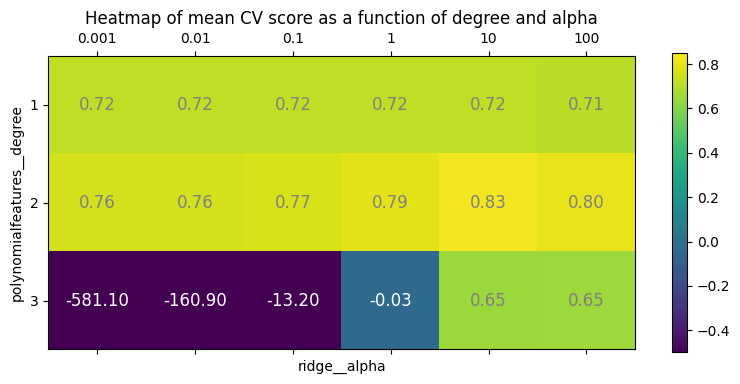

In [71]:
mean_test_score = grid.cv_results_['mean_test_score'].reshape(3,6)

fig,ax = plt.subplots(figsize=(8,4))
im = ax.matshow(mean_test_score, vmin=-0.5, vmax=0.85)

xticks = range(len(param_grid['ridge__alpha']))
yticks = range(len(param_grid['polynomialfeatures__degree']))

for i in yticks:
    for j in xticks:
        ax.text(j, i, '{:.2f}'.format(mean_test_score[i,j]),
               ha='center', va='center', size=12,
               color = 'gray' if mean_test_score[i,j]>0 else 'white')

ax.set_xticks(xticks, labels=param_grid['ridge__alpha'])
ax.set_yticks(yticks, labels=param_grid['polynomialfeatures__degree'])
ax.set_xlabel('ridge__alpha')
ax.set_ylabel('polynomialfeatures__degree')
ax.set_title('Heatmap of mean CV score as a function of degree and alpha')

fig.tight_layout()
plt.colorbar(im)
plt.show()

A polynomial of degree 2 would be the best in this case, and moving further to degree 3 leads to bad results. We can see from the heatmap that, over our chosen grid, the best model would be a polynomial of degree 2 and a ridge alpha of 10.

In [72]:
best_params = grid.best_params_
print('Best parameters: {}'.format(best_params))

Best parameters: {'polynomialfeatures__degree': 2, 'ridge__alpha': 10}


In [75]:
test_score = grid.score(X_test, y_test)
print('Test-set score: {:.2f}'.format(test_score))

Test-set score: 0.77


For comparison, let's check the test score without polynomial features.

In [76]:
param_grid = {'ridge__alpha': [0.001, 0.01, 0.1, 1, 10, 100]}
pipe = make_pipeline(StandardScaler(), Ridge())
grid = GridSearchCV(pipe, param_grid)
grid.fit(X_train_val, y_train_val)
score = grid.score(X_test, y_test)

print('Score without poly features: {:.2f}'.format(score))

Score without poly features: 0.63


## Grid-Searching Which Model To Use

We can grid-search over which steps to be performed in the pipeline (e.g., whether to use `StandardScaler` or `MinMaxScaler`).

### Example: Random Forest vs. Support Vector Machines on the Cancer dataset

Here The SVC might require scaling the data, while the random forest does not. So, we will consider both 'with preprocessing' and 'without preprocessing' in the grid search.

In [79]:
from sklearn.ensemble import RandomForestClassifier

#Instantiate the pipeline
# These are just initial values, and they will change throughout the grid search
# We have to explicitly define the names of the steps so we define the pipeline the long way...
pipe = Pipeline([('scaler', StandardScaler()), ('classifier', SVC())])

# Define the parameter grid
# Some parameters will be used by one classifier, others will not be used
# So, we have to separate
param_grid = [
    {'classifier': [SVC()], 'scaler': [StandardScaler(), None],
     'classifier__gamma': [0.001, 0.01, 0.1, 1, 10, 100],
     'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100]},
    {'classifier': [RandomForestClassifier(n_estimators=100)], 'scaler': [None],
     'classifier__max_features': [1, 2, 3]}
]

# Instantiate the grid search
grid = GridSearchCV(pipe, param_grid, n_jobs=-1)

# Prepare the breast cancer dataset
X = dataset.data
y = dataset.target
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, random_state=0)

# Fit the grid
grid.fit(X_train_val, y_train_val)

# Evaluation
best_params = grid.best_params_
best_cv_score = grid.best_score_
test_score = grid.score(X_test, y_test)

print('Best params:\n {}'.format(best_params))
print('\nBest cross-validation score: {:.2f}'.format(best_cv_score))
print('Test-set score: {:.2f}'.format(test_score))

Best params:
 {'classifier': SVC(), 'classifier__C': 10, 'classifier__gamma': 0.01, 'scaler': StandardScaler()}

Best cross-validation score: 0.99
Test-set score: 0.98
